# Thành viên 3 (EDA 1): Phân tích thống kê tổng quan và Cấu trúc

## 1. Phân tích phân bố nhãn (Label distribution)
Vẽ biểu đồ Bar/Pie chart, đánh giá mức độ mất cân bằng dữ liệu (Imbalanced data).

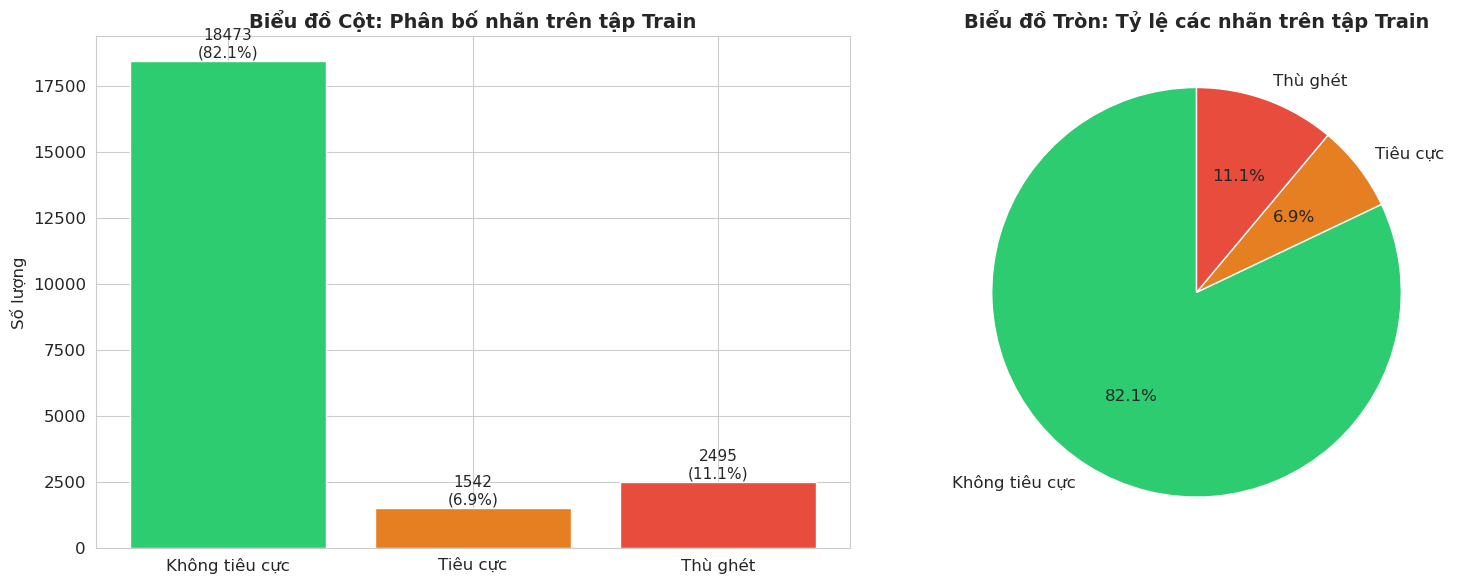

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Save dir
os.makedirs('../output/eda', exist_ok=True)
SAVE_DIR = Path('../output/eda')

# Cấu hình đồ thị
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Tên nhãn và màu sắc
LABEL_NAMES = {0: 'Không tiêu cực', 1: 'Tiêu cực', 2: 'Thù ghét'}
COLORS = ['#2ecc71', '#e67e22', '#e74c3c']

# Đọc dữ liệu đã tiền xử lý
train = pd.read_csv('../data/train_clean.csv')
dev = pd.read_csv('../data/dev_clean.csv')
test = pd.read_csv('../data/test_clean.csv')

# Vẽ biểu đồ Bar/Pie chart cho tập Train
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ Bar
counts = train['label_id'].value_counts().sort_index()
bars = axes[0].bar([LABEL_NAMES[i] for i in counts.index], counts.values, color=COLORS)
axes[0].set_title('Biểu đồ Cột: Phân bố nhãn trên tập Train', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số lượng')

for bar, val in zip(bars, counts.values):
    pct = val / train.shape[0] * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

# Biểu đồ Pie
axes[1].pie(counts.values, labels=[LABEL_NAMES[i] for i in counts.index], colors=COLORS, 
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Biểu đồ Tròn: Tỷ lệ các nhãn trên tập Train', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR / Path('label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Dựa trên biểu đồ cột và biểu đồ tròn, ta thấy tập dữ liệu **mất cân bằng nghiêm trọng (highly imbalanced)**.
- Nhãn **"Không tiêu cực" (Label 0)** chiếm đa số tuyệt đối với tỷ lệ hơn 80% (có thể dao động cụ thể trên tập dữ liệu của mình).
- Các nhãn **"Tiêu cực" (Label 1)** và **"Thù ghét" (Label 2)** chiếm tỷ lệ rất nhỏ.
- **Hệ quả:** Sự chênh lệch này đòi hỏi phải áp dụng các kỹ thuật xử lý mất cân bằng dữ liệu (như Oversampling, Undersampling, SMOTE, hoặc sử dụng class weights) trong quá trình huấn luyện mô hình để tránh việc mô hình bị bias theo lớp đa số.

## 2. So sánh sự phân bố của các nhãn giữa 3 tập train, dev, test
So sánh sự phân bố của các nhãn giữa 3 tập train, dev, test để xem cách chia dữ liệu đã tốt hay chưa.

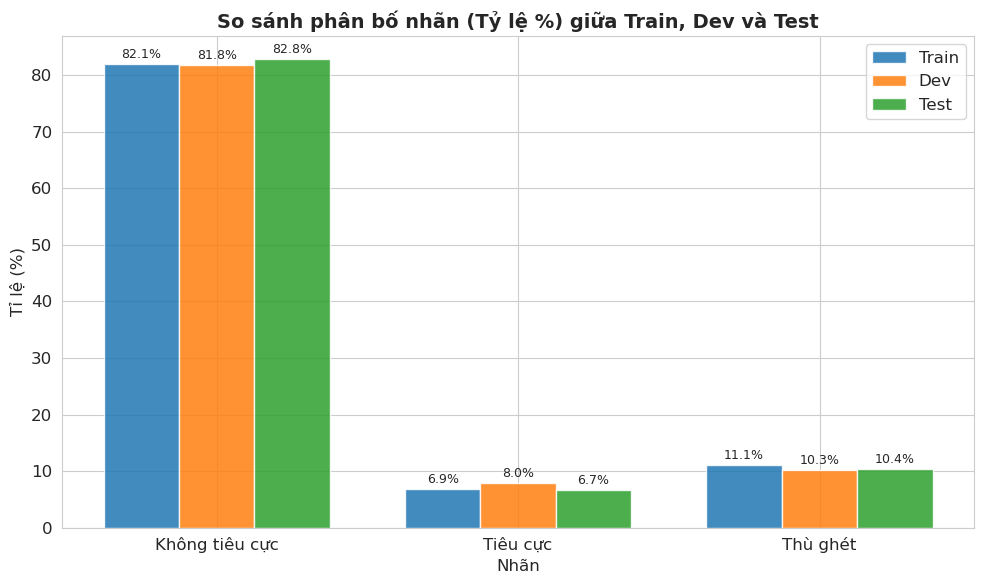

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.25

for idx, (name, df) in enumerate([('Train', train), ('Dev', dev), ('Test', test)]):
    pcts = [df[df['label_id']==l].shape[0] / df.shape[0] * 100 for l in [0, 1, 2]]
    bars = ax.bar(x + idx*width, pcts, width, label=name, alpha=0.85)
    
    # Thêm text phần trăm lên cột
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, 
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Nhãn', fontsize=12)
ax.set_ylabel('Tỉ lệ (%)', fontsize=12)
ax.set_title('So sánh phân bố nhãn (Tỷ lệ %) giữa Train, Dev và Test', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([LABEL_NAMES[i] for i in range(3)])
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / Path('train_dev_test_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Phân bố tỷ lệ của các nhãn giữa 3 tập Train, Dev, Test gần như **tương đồng với nhau**.
- Việc phân tách tập dữ liệu đã giữ được tỷ lệ tương đương của các nhãn trong từng tập.
- **Kết luận:** Cách phân chia tập dữ liệu hiện tại (train/dev/test split) đã được thực hiện rất tốt, đảm bảo tính đại diện. Mô hình học được từ tập Train sẽ phản ánh đúng cấu trúc phân bố trên tập Dev và Test, giúp cho quá trình đánh giá (evaluation) đáng tin cậy hơn.

## 3. Thống kê độ dài văn bản (Số từ/Số ký tự)
Tìm mean, median, max, min, và vẽ Histogram/Boxplot phân bố độ dài câu theo từng nhãn.

BẢNG THỐNG KÊ ĐỘ DÀI VĂN BẢN VÀ SỐ TỪ THEO TỪNG NHÃN (TẬP TRAIN):



,Count,Length_Min,Length_Max,Length_Mean,Length_Median,Words_Min,Words_Max,Words_Mean,Words_Median
Không tiêu cực,18473,1,7084,43.74,32.0,1,1550,10.59,8.0
Tiêu cực,1542,1,368,43.96,30.0,1,91,10.89,8.0
Thù ghét,2495,4,671,83.37,59.0,1,166,20.42,15.0


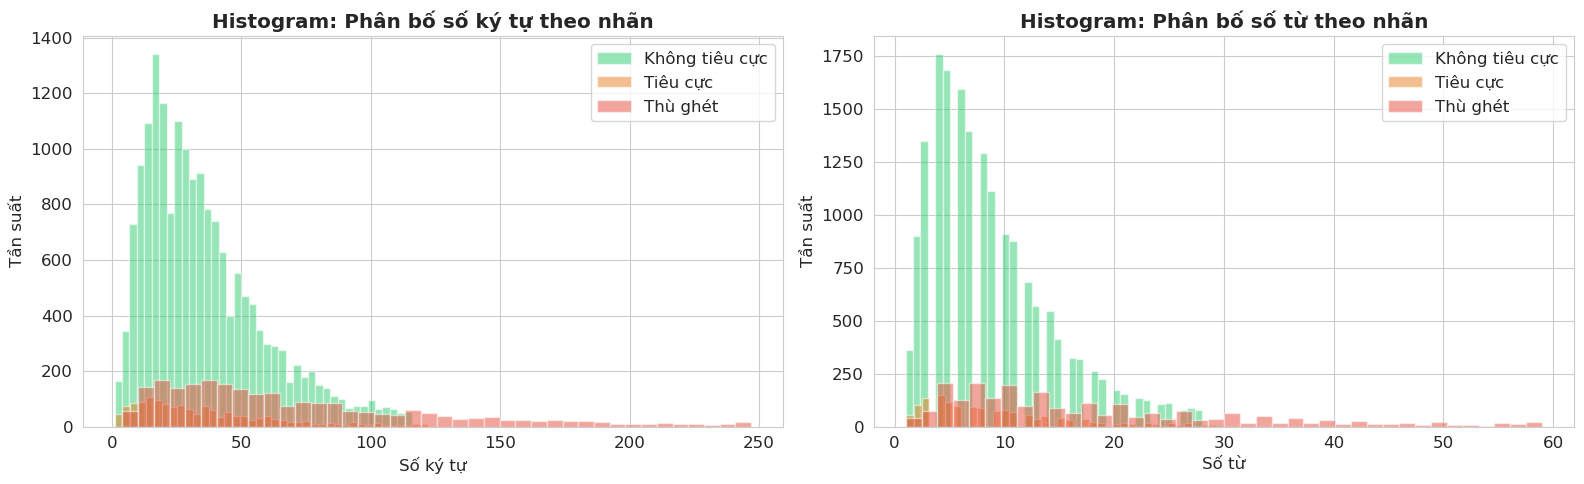

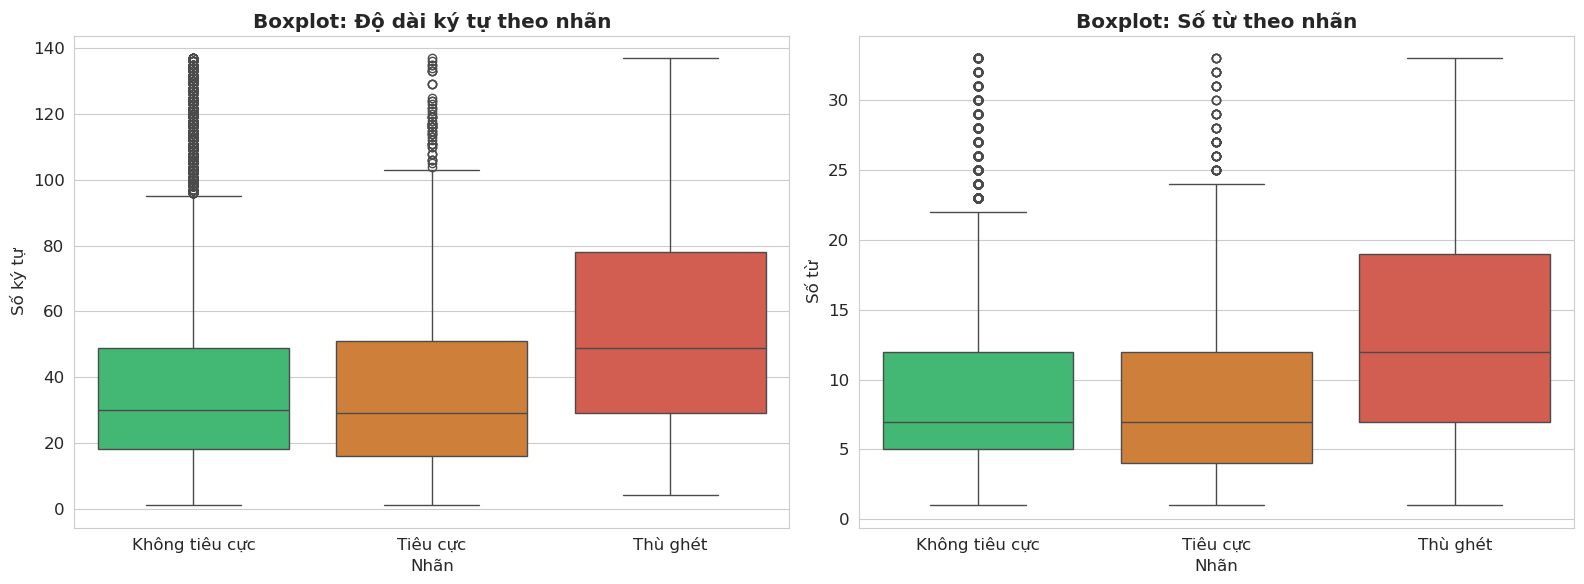

In [3]:
# Tính toán độ dài ký tự và số từ cho tập train
train['text_length'] = train['free_text_clean'].astype(str).str.len()
train['word_count'] = train['free_text_clean'].astype(str).str.split().str.len()

# 1. Bảng thống kê Mean, Median, Max, Min
print("BẢNG THỐNG KÊ ĐỘ DÀI VĂN BẢN VÀ SỐ TỪ THEO TỪNG NHÃN (TẬP TRAIN):\n")
stats_df = train.groupby('label_id').agg(
    Count=('label_id', 'size'),
    Length_Min=('text_length', 'min'),
    Length_Max=('text_length', 'max'),
    Length_Mean=('text_length', 'mean'),
    Length_Median=('text_length', 'median'),
    Words_Min=('word_count', 'min'),
    Words_Max=('word_count', 'max'),
    Words_Mean=('word_count', 'mean'),
    Words_Median=('word_count', 'median')
).round(2)
stats_df.index = [LABEL_NAMES[i] for i in stats_df.index]
display(stats_df)

# 2. Vẽ Histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for label in [0, 1, 2]:
    # Lọc quantile 0.95 để loại bỏ outlier giúp biểu đồ dễ nhìn hơn
    subset_char = train[train['label_id'] == label]['text_length']
    subset_char = subset_char[subset_char <= subset_char.quantile(0.95)]
    axes[0].hist(subset_char, bins=40, alpha=0.5, label=LABEL_NAMES[label], color=COLORS[label])
    
    subset_word = train[train['label_id'] == label]['word_count']
    subset_word = subset_word[subset_word <= subset_word.quantile(0.95)]
    axes[1].hist(subset_word, bins=40, alpha=0.5, label=LABEL_NAMES[label], color=COLORS[label])

axes[0].set_title('Histogram: Phân bố số ký tự theo nhãn', fontweight='bold')
axes[0].set_xlabel('Số ký tự')
axes[0].set_ylabel('Tần suất')
axes[0].legend()

axes[1].set_title('Histogram: Phân bố số từ theo nhãn', fontweight='bold')
axes[1].set_xlabel('Số từ')
axes[1].set_ylabel('Tần suất')
axes[1].legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / Path('length_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3. Vẽ Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sử dụng tập dữ liệu đã lọc quantile 0.95 để vẽ boxplot
train_filtered_char = train[train['text_length'] <= train['text_length'].quantile(0.95)]
train_filtered_word = train[train['word_count'] <= train['word_count'].quantile(0.95)]

sns.boxplot(data=train_filtered_char, x='label_id', y='text_length', palette=COLORS, ax=axes[0])
axes[0].set_xticklabels([LABEL_NAMES[i] for i in range(3)])
axes[0].set_title('Boxplot: Độ dài ký tự theo nhãn', fontweight='bold')
axes[0].set_xlabel('Nhãn')
axes[0].set_ylabel('Số ký tự')

sns.boxplot(data=train_filtered_word, x='label_id', y='word_count', palette=COLORS, ax=axes[1])
axes[1].set_xticklabels([LABEL_NAMES[i] for i in range(3)])
axes[1].set_title('Boxplot: Số từ theo nhãn', fontweight='bold')
axes[1].set_xlabel('Nhãn')
axes[1].set_ylabel('Số từ')

plt.tight_layout()
plt.savefig(SAVE_DIR / Path('length_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- **Mean/Median:** Nhìn vào bảng thống kê, các đoạn văn bản trung bình dài khoảng vài chục ký tự (tương đương khoảng hơn chục từ). Median luôn nhỏ hơn Mean cho thấy phân bố độ dài văn bản bị lệch phải (right-skewed), nghĩa là phần lớn các câu khá ngắn, nhưng có một số lượng nhỏ các câu rất dài kéo giá trị trung bình lên cao.
- **Max/Min:** Số lượng từ ít nhất có thể rất nhỏ, và cực đại lên tới vài trăm từ/ngàn ký tự. Có sự xuất hiện của các văn bản ngoại lai (outliers) có độ dài quá lớn.
- **Histogram & Boxplot:** Hình ảnh phân bố xác nhận lại tính lệch phải của dữ liệu. Qua Boxplot, ta thấy phân bố (IQR) của độ dài ký tự và số từ giữa các nhãn khá tương đồng, tuy nhiên có lượng lớn các outlier ở trên râu (whisker) trên của boxplot.

## 4. Phân tích tương quan giữa độ dài văn bản và nhãn

Kiểm định mối quan hệ thống kê giữa độ dài văn bản và nhãn phân loại bằng:
- **Point-biserial correlation**: tương quan giữa biến liên tục (độ dài) và biến nhị phân (từng nhãn)
- **ANOVA một chiều**: kiểm định sự khác biệt độ dài trung bình giữa các nhóm nhãn

In [4]:
from scipy import stats as scipy_stats

# Đảm bảo đã có cột char_len và word_count
if 'char_len' not in train.columns:
    train['char_len'] = train['free_text_clean'].astype(str).str.len()
if 'word_count' not in train.columns:
    train['word_count'] = train['free_text_clean'].astype(str).str.split().str.len()

print('=== TƯƠNG QUAN POINT-BISERIAL: ĐỘ DÀI KÝ TỰ vs NHÃN ===')
print(f'{"Nhãn":<15} {"Hệ số r":>10} {"p-value":>12} {"Kết luận"}')
print('-' * 65)
for lid in [0, 1, 2]:
    binary = (train['label_id'] == lid).astype(int)
    r, p = scipy_stats.pointbiserialr(binary, train['char_len'])
    sig = 'Có ý nghĩa (p<0.001)' if p < 0.001 else f'p={p:.3f}'
    direction = 'dương' if r > 0 else 'âm'
    strength = 'yếu' if abs(r) < 0.2 else 'trung bình' if abs(r) < 0.5 else 'mạnh'
    print(f'{LABEL_NAMES[lid]:<15} {r:>+10.4f} {p:>12.2e}  Tương quan {direction} {strength} — {sig}')

print()
print('=== KIỂM ĐỊNH ANOVA MỘT CHIỀU: ĐỘ DÀI THEO NHÃN ===')
groups = [train[train['label_id'] == l]['char_len'] for l in [0, 1, 2]]
f_stat, p_val = scipy_stats.f_oneway(*groups)
print(f'F-statistic = {f_stat:.2f}')
print(f'p-value     = {p_val:.2e}')
print(f'Kết luận: Sự khác biệt về độ dài giữa các nhóm nhãn {"CÓ" if p_val < 0.05 else "KHÔNG"} ý nghĩa thống kê (α=0.05)')

print()
print('=== ĐỘ DÀI TRUNG BÌNH THEO NHÃN ===')
for lid in [0, 1, 2]:
    subset = train[train['label_id'] == lid]['char_len']
    print(f'{LABEL_NAMES[lid]}: mean={subset.mean():.1f}, median={subset.median():.0f}, std={subset.std():.1f}')


=== TƯƠNG QUAN POINT-BISERIAL: ĐỘ DÀI KÝ TỰ vs NHÃN ===
Nhãn               Hệ số r      p-value Kết luận
-----------------------------------------------------------------
Không tiêu cực     -0.1120     8.67e-64  Tương quan âm yếu — Có ý nghĩa (p<0.001)
Tiêu cực           -0.0135     4.30e-02  Tương quan âm yếu — p=0.043
Thù ghét           +0.1478    4.51e-110  Tương quan dương yếu — Có ý nghĩa (p<0.001)

=== KIỂM ĐỊNH ANOVA MỘT CHIỀU: ĐỘ DÀI THEO NHÃN ===
F-statistic = 251.21
p-value     = 1.26e-108
Kết luận: Sự khác biệt về độ dài giữa các nhóm nhãn CÓ ý nghĩa thống kê (α=0.05)

=== ĐỘ DÀI TRUNG BÌNH THEO NHÃN ===
Không tiêu cực: mean=43.7, median=32, std=86.8
Tiêu cực: mean=44.0, median=30, std=45.9
Thù ghét: mean=83.4, median=59, std=74.0


**Nhận xét:**
- Kiểm định ANOVA cho thấy sự khác biệt về độ dài văn bản giữa các nhóm nhãn **có ý nghĩa thống kê** (F=251.21, p<0.001).
- Nhãn **HATE** tương quan dương với độ dài (r=+0.148) — bình luận thù ghét có xu hướng dài hơn.
- Nhãn **CLEAN** tương quan âm nhẹ (r=-0.112) — bình luận sạch thường ngắn hơn mức trung bình.
- Nhãn **OFFENSIVE** không có tương quan đáng kể với độ dài (r=-0.014).
- **Kết luận:** Độ dài văn bản có tiềm năng là một đặc trưng phụ trợ (auxiliary feature) giúp mô hình phân biệt nhãn HATE.